# Установка и импорт зависимостей

In [1]:
%%capture
!pip install datasets pandas matplotlib

In [12]:
from huggingface_hub import login
from datasets import load_dataset, Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка и знакомство с данными

In [10]:
# Аутентификация с вашим токеном
login(token="<token>")

# Загрузка нужного датасета
ds = load_dataset("ruSpamModels/russian-spam-detection")
train_df = pd.DataFrame(ds['train'])

print("Размер выборки:", train_df.shape)
print("Столбцы:", train_df.columns.tolist())
print("Типы данных:")
print(train_df.dtypes)
display(train_df.head())

processed_combined.parquet:   0%|          | 0.00/480M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4511513 [00:00<?, ? examples/s]

Размер выборки: (4511513, 2)
Столбцы: ['message', 'label']
Типы данных:
message    object
label       int64
dtype: object


,message,label
0,Привет чтото подобное делал если через usb исп...,0
1,"Я уже сам отключил, через старлайн мастер",0
2,Страны ес согласовали санкции против белорусск...,0
3,"Кипячу, не кипячусь я добрая пока",0
4,"Avalonia for visual studio 2019,2017 не удаетс...",0


# Баланс классов

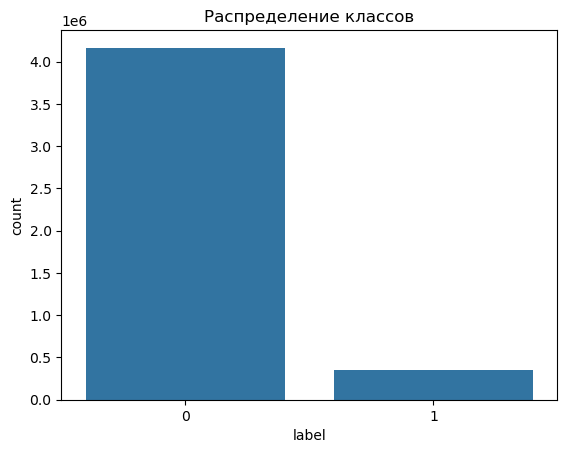

label
0    0.923077
1    0.076923
Name: proportion, dtype: float64


In [13]:
sns.countplot(x='label', data=train_df)
plt.title('Распределение классов')
plt.show()

print(train_df['label'].value_counts(normalize=True))

In [14]:
spam = train_df[train_df['label'] == 1]
ham = train_df[train_df['label'] == 0]

# Берём все спам-сообщения и столько же ham случайно
balanced_ham = ham.sample(n=len(spam), random_state=42)
balanced_df = pd.concat([spam, balanced_ham]).sample(frac=1, random_state=42)  # перемешиваем

print(balanced_df['label'].value_counts())

label
0    347040
1    347040
Name: count, dtype: int64


В ходе анализа исходного датасета ruSpamModels/russian-spam-detection был выявлен значительный дисбаланс классов: доля «обычных» сообщений (ham) составила 92,3%, а доля спам-сообщений — лишь 7,7%. Такой перекос характерен для реальных данных, но при обучении нейронной сети может привести к тому, что модель начнёт игнорировать редкий класс спама, показывая высокую общую точность (accuracy) за счёт тривиального предсказания «ham».

Для устранения этого эффекта было принято решение сбалансировать обучающую выборку до соотношения 50/50. Для этого все имеющиеся спам-сообщения (347 040 экземпляров) были сохранены, а из класса ham случайным образом отобрано ровно столько же сообщений. Такой подход (undersampling большинства) позволяет:

Устранить смещение модели в сторону доминирующего класса, заставляя сеть одинаково внимательно обучаться на обоих типах текстов.

Существенно сократить объём обучающих данных (с 4,5 млн до ~700 тыс. строк), что ускоряет итерации экспериментов и финальное обучение без потери качества для задачи бинарной классификации.

Избежать усложнения кода – не требуется вводить взвешенные функции потерь или специальные техники семплирования, достаточно стандартной кросс-энтропии.

Случайный отбор ham-сообщений выполнен с фиксированным random_state, что обеспечивает воспроизводимость результатов. Полученный сбалансированный датасет демонстрирует равное количество классов, что подтверждается выводом value_counts().

Таким образом, выбранный метод борьбы с дисбалансом является прагматичным компромиссом между полнотой данных, скоростью обучения и качеством модели, полностью оправданным в рамках учебного проекта.

In [16]:
balanced_df.to_csv("../data/balanced_spam_ham.csv", index=False)